# Preprocessing

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,RobustScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

In [87]:
FILE_PATH = os.path.join(os.getcwd(), 'Dataset','final_internship_data.csv')
df = pd.read_csv(FILE_PATH)

In [88]:
print("\n--- Descriptive statistics (numeric) ---")
print(df.describe().T.to_string())

print("\n--- Descriptive statistics (object) ---")
print(df.describe(include="object").T.to_string())


--- Descriptive statistics (numeric) ---
                      count         mean          std          min          25%          50%          75%           max
fare_amount        500000.0    11.358361     9.916617   -44.900000     6.000000     8.500000    12.500000    500.000000
pickup_longitude   500000.0    -1.265712     0.206941   -52.119764    -1.291405    -1.291226    -1.290970     37.360538
pickup_latitude    500000.0     0.696740     0.140909   -54.389440     0.710958     0.711268     0.711520     29.724576
dropoff_longitude  499995.0    -1.265755     0.205903   -59.049665    -1.291393    -1.291197    -1.290908      0.712985
dropoff_latitude   499995.0     0.696675     0.128997   -44.676047     0.710943     0.711277     0.711538      7.061893
passenger_count    500000.0     1.683428     1.307395     0.000000     1.000000     1.000000     2.000000      6.000000
hour               500000.0    13.510834     6.511571     0.000000     9.000000    14.000000    19.000000     23.00000

In [89]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df.dropna(inplace=True)
df.drop(columns=['user_id', 'key', 'pickup_datetime', 'user_name', 'driver_name'], inplace=True)
df.drop(columns=['pickup_latitude','pickup_longitude', 'dropoff_latitude','dropoff_longitude'], inplace=True)
df.columns

Index(['car_condition', 'weather', 'traffic_condition', 'fare_amount',
       'passenger_count', 'hour', 'day', 'month', 'weekday', 'year',
       'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance',
       'bearing'],
      dtype='object')

In [ ]:
# Drop missing/invalid coords first
d = df.dropna(subset=['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']).copy()

# Optional: keep only roughly valid NYC-like ranges (edit for your city)
d = d[
    d['pickup_latitude'].between(-90, 90) &
    d['pickup_longitude'].between(-180, 180) &
    d['dropoff_latitude'].between(-90, 90) &
    d['dropoff_longitude'].between(-180, 180)
]

# Center map
center = [d['pickup_latitude'].mean(), d['pickup_longitude'].mean()]
m = folium.Map(location=center, zoom_start=11)

# Use a sample for speed (50k is usually enough visually)
s = d.sample(min(50000, len(d)), random_state=42)

pickup_pts  = s[['pickup_latitude','pickup_longitude']].values.tolist()
dropoff_pts = s[['dropoff_latitude','dropoff_longitude']].values.tolist()

HeatMap(pickup_pts,  name='Pickup Heat',  radius=8, blur=6).add_to(m)
HeatMap(dropoff_pts, name='Dropoff Heat', radius=8, blur=6).add_to(m)

folium.LayerControl().add_to(m)
m.save("map.html")

In [91]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- Value counts for {col} ---")
    print(df[col].value_counts().to_string())


--- Value counts for car_condition ---
car_condition
Very Good    125310
Bad          124977
Good         124967
Excellent    124741

--- Value counts for weather ---
weather
sunny     100433
cloudy    100060
rainy      99971
stormy     99955
windy      99576

--- Value counts for traffic_condition ---
traffic_condition
Congested Traffic    166846
Dense Traffic        166581
Flow Traffic         166568


In [92]:
df = df[df["fare_amount"] >= 0]

In [ ]:
print(df.groupby('car_condition')['fare_amount'].mean())
print(df.groupby('weather')['fare_amount'].mean())
print(df.groupby('traffic_condition')['fare_amount'].mean())

car_condition
Bad          11.326867
Excellent    11.355407
Good         11.337315
Very Good    11.415951
Name: fare_amount, dtype: float64
weather
cloudy    11.380603
rainy     11.358564
stormy    11.347175
sunny     11.359245
windy     11.348979
Name: fare_amount, dtype: float64
traffic_condition
Congested Traffic    11.391427
Dense Traffic        11.368025
Flow Traffic         11.317270
Name: fare_amount, dtype: float64


In [94]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

cat_cols = ["Car Condition", "Weather", "Traffic Condition"]
num_cols = df.select_dtypes(include='number').columns

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((399979, 16), (99995, 16), (399979,), (99995,))

In [ ]:
# fare_amount — keep zeros but remove extreme highs
mask = y_train <= 200  

# distance — keep zeros but remove extreme highs
mask &= X_train['distance'] <= 20

X_train = X_train[mask]
y_train = y_train[mask]

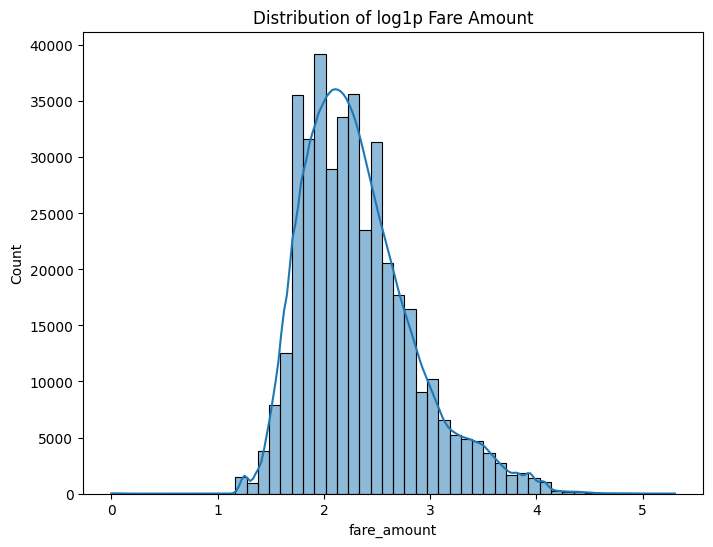

In [97]:
plt.figure(figsize=(8,6))
sns.histplot(np.log1p(y_train), bins=50, kde=True)
plt.title('Distribution of log1p Fare Amount')
plt.show()

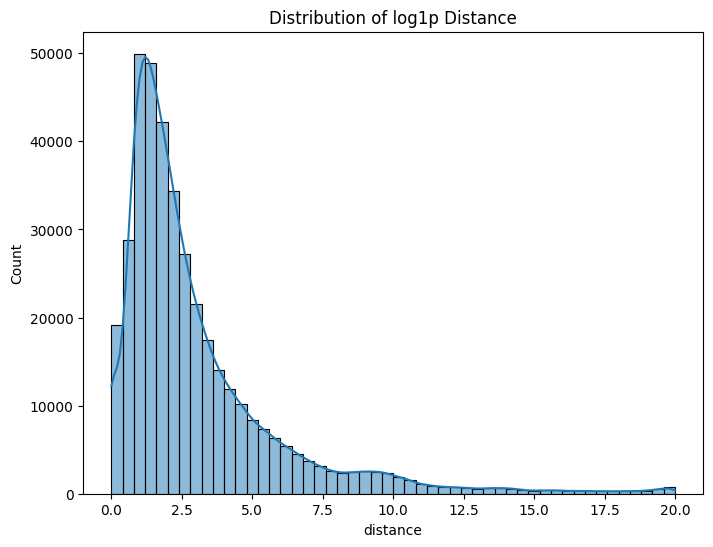

In [98]:
plt.figure(figsize=(8,6))
sns.histplot(X_train['distance'], bins=50, kde=True)
plt.title('Distribution of log1p Distance')
plt.show()

In [ ]:
# Log-transform distance 
X_train['distance'] = np.log1p(X_train['distance'])
X_test['distance'] = np.log1p(X_test['distance'])

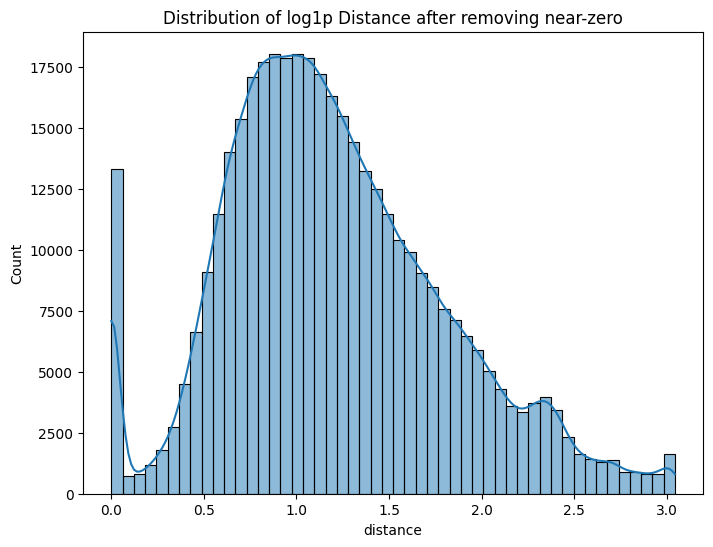

In [100]:
plt.figure(figsize=(8,6))
sns.histplot(X_train['distance'], bins=50, kde=True)
plt.title('Distribution of log1p Distance after removing near-zero')
plt.show()

In [101]:
dist_cols     = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist']
ordinal_cols  = ['car_condition']
onehot_cols   = ['weather', 'traffic_condition']
numeric_cols  = ['passenger_count', 'hour', 'day', 'month', 'weekday', 
                 'year', 'distance', 'bearing']

preprocessor = ColumnTransformer(transformers=[
    ('airport_pca', Pipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=1))
    ]), dist_cols),
    
    ('ordinal', OrdinalEncoder(
        categories=[['Bad', 'Good', 'Very Good', 'Excellent']]
    ), ordinal_cols),
    
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), onehot_cols),
    
    ('numeric', RobustScaler(), numeric_cols)
])

# Training model & Evaluation

In [102]:
models = {
    'Ridge'        : Ridge(),
    'RandomForest' : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost'      : XGBRegressor(n_estimators=200, learning_rate=0.01, random_state=42),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, np.log1p(y_train))
    preds = np.expm1(pipe.predict(X_test))

    results[name] = {
        'MAE' : mean_absolute_error(y_test, preds),
        'MSE' : mean_squared_error(y_test, preds),
        'RMSE': root_mean_squared_error(y_test, preds),
        'R2'  : r2_score(y_test, preds)
    }

print(pd.DataFrame(results).T.sort_values('MAE'))

                    MAE           MSE        RMSE          R2
RandomForest   1.933666     24.641369    4.964007    0.747653
XGBoost        2.412526     31.978780    5.654978    0.672512
Ridge         11.881596  50011.204977  223.631851 -511.154714


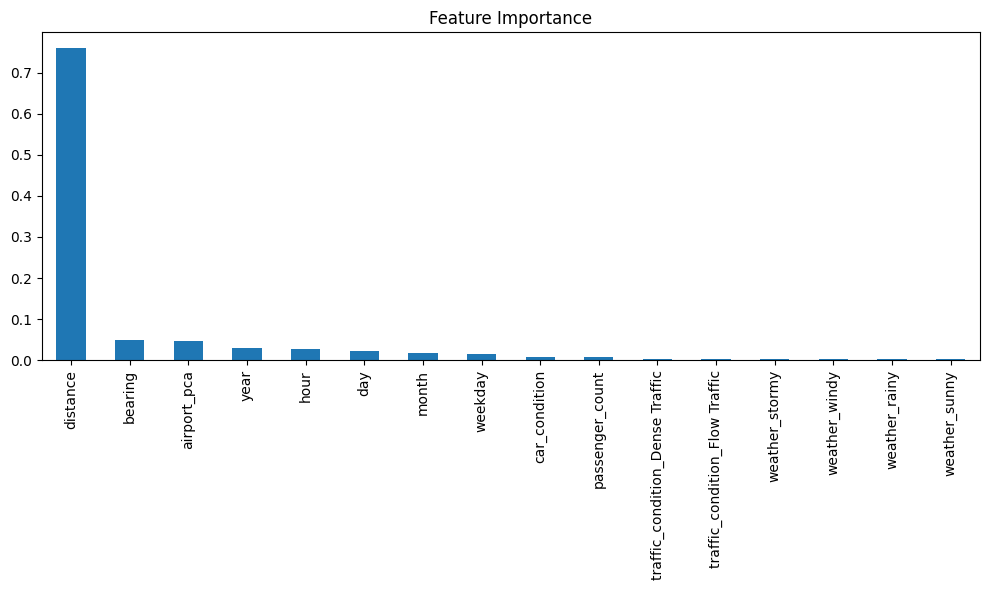

distance                           0.759746
bearing                            0.049090
airport_pca                        0.045852
year                               0.030327
hour                               0.026904
day                                0.022734
month                              0.017277
weekday                            0.014241
car_condition                      0.008418
passenger_count                    0.007009
traffic_condition_Dense Traffic    0.003286
traffic_condition_Flow Traffic     0.003179
weather_stormy                     0.003038
weather_windy                      0.003016
weather_rainy                      0.002947
weather_sunny                      0.002936
dtype: float64


In [ ]:
feature_names = (
    ['airport_pca'] +
    ['car_condition'] +
    list(preprocessor
         .named_transformers_['onehot']
         .get_feature_names_out(['weather', 'traffic_condition'])) +
    ['passenger_count', 'hour', 'day', 'month', 'weekday', 'year', 'distance', 'bearing']
)

# Train Random Forest with categoricals
rf_pipe_cats = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipe_cats.fit(X_train, np.log1p(y_train))

# Plot
importances = rf_pipe_cats['model'].feature_importances_
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance_df.plot(kind='bar')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

print(importance_df)

In [ ]:
# Cross Validation
rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])


kf = KFold(n_splits=3, shuffle=True, random_state=42)

cv_r2  = cross_val_score(rf_pipe, X_train, np.log1p(y_train), cv=kf, scoring='r2')
cv_mae = cross_val_score(rf_pipe, X_train, np.log1p(y_train), cv=kf, scoring='neg_mean_absolute_error')

print(f"R² per fold  : {cv_r2.round(4)}")
print(f"R² mean      : {cv_r2.mean().round(4)}")
print(f"R² std       : {cv_r2.std().round(4)}\n")
print(f"MAE per fold : {(-cv_mae).round(4)}")
print(f"MAE mean     : {(-cv_mae).mean().round(4)}")
print(f"MAE std      : {(-cv_mae).std().round(4)}")

R² per fold  : [0.7935 0.7899 0.7902]
R² mean      : 0.7912
R² std       : 0.0016

MAE per fold : [0.15   0.1496 0.1499]
MAE mean     : 0.1498
MAE std      : 0.0002
